In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D,
    BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping,
    ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.regularizers import l2

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32

# ── Stage 1: train only the head (frozen base) ──────────────────────────────
STAGE1_LR     = 1e-3
STAGE1_EPOCHS = 20

# ── Stage 2: fine-tune last N blocks of ResNet50 ────────────────────────────
STAGE2_LR       = 5e-5
STAGE2_EPOCHS   = 40
UNFREEZE_LAYERS = 40   # unfreeze last 40 layers of ResNet50

DATASET_PATH = "/content/drive/MyDrive/brain-tumor-classification/data/processed/Training"
MODEL_SAVE_PATH = "/content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

In [4]:
# ── CLAHE Preprocessing ──────────────────────────────────────────────────────
# CLAHE (Contrast Limited Adaptive Histogram Equalization) enhances MRI contrast
def apply_clahe(img_bgr):
    """Apply CLAHE on the L channel of LAB color space for better MRI contrast."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return enhanced


# ── Dataset Loader ───────────────────────────────────────────────────────────
def load_dataset(base_path, apply_enhancement=True):
    """
    Load images from folder structure:
      base_path/
        class_A/img1.jpg ...
        class_B/img1.jpg ...
    Returns X (uint8 RGB), y (int labels), class_names
    """
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])
    print(f"Found {len(class_names)} classes: {class_names}")

    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        files = [f for f in os.listdir(cls_folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]
        print(f"  {cls}: {len(files)} images")

        for img_name in files:
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            # CLAHE enhancement (works on BGR)
            if apply_enhancement:
                img = apply_clahe(img)

            # Convert to RGB
            if len(img.shape) == 2:  # grayscale
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)

    X = np.array(X, dtype=np.uint8)
    y = np.array(y, dtype=np.int32)
    print(f"\nTotal loaded: {len(X)} images")
    return X, y, class_names


X, y, class_names = load_dataset(DATASET_PATH)
NUM_CLASSES = len(class_names)
print("Shape:", X.shape, y.shape)
print("Classes:", class_names)

Found 4 classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 826 images
  meningioma_tumor: 822 images
  no_tumor: 395 images
  pituitary_tumor: 827 images

Total loaded: 2870 images
Shape: (2870, 224, 224, 3) (2870,)
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


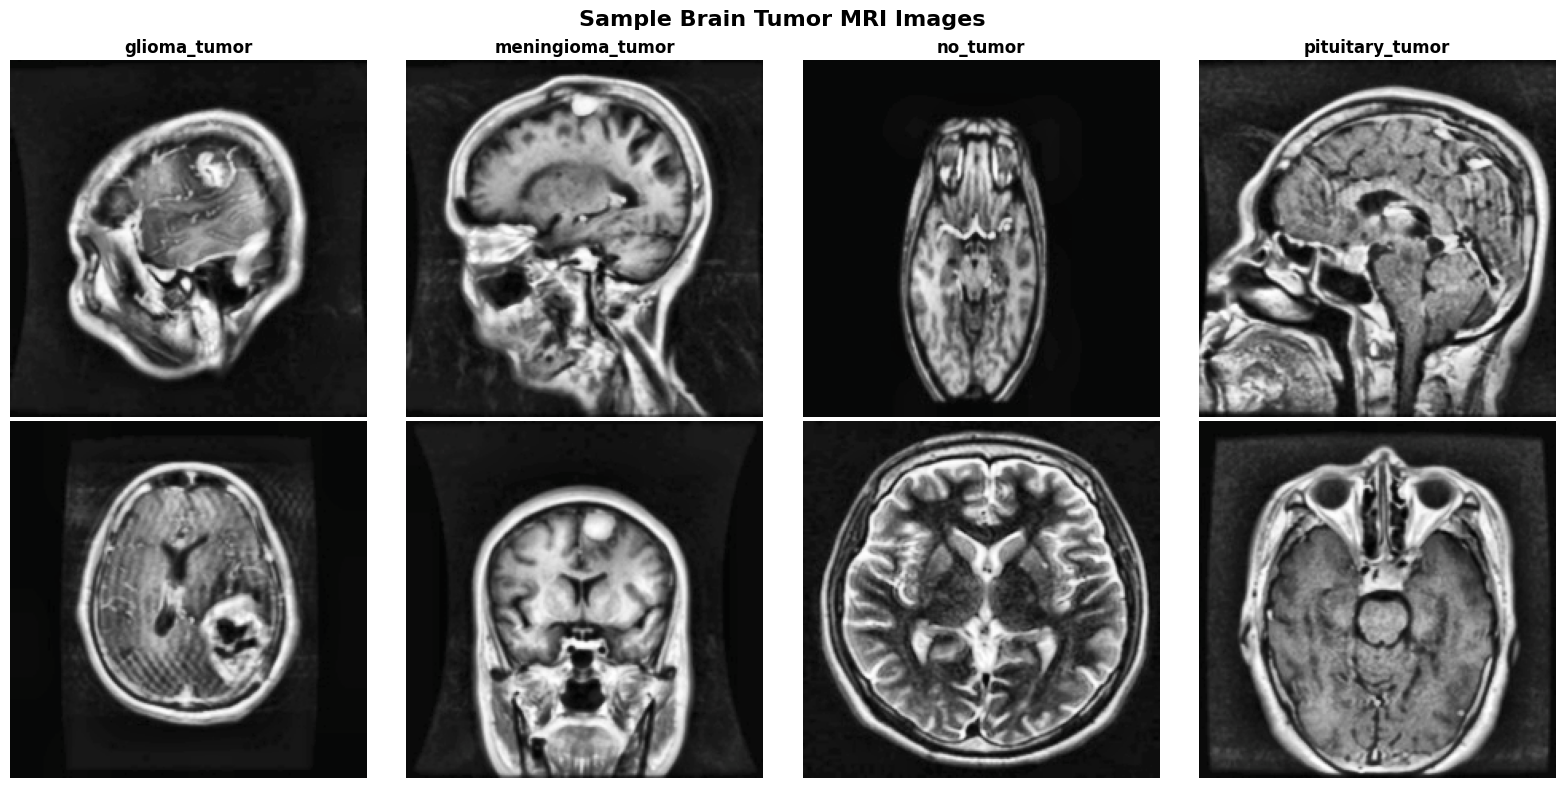

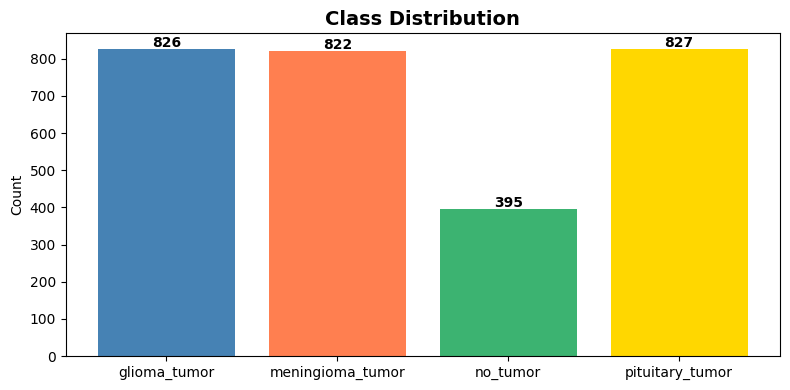

In [5]:
# ── Visualise sample images ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 8))
for c in range(NUM_CLASSES):
    idxs = np.where(y == c)[0]
    for row in range(2):
        ax = axes[row, c] if NUM_CLASSES > 1 else axes[row]
        ax.imshow(X[idxs[row]])
        ax.axis('off')
        if row == 0:
            ax.set_title(class_names[c], fontsize=12, fontweight='bold')
plt.suptitle("Sample Brain Tumor MRI Images", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Class distribution
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 4))
bars = plt.bar([class_names[u] for u in unique], counts,
               color=['steelblue', 'coral', 'mediumseagreen', 'gold'][:NUM_CLASSES])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ── Train / Val / Test Split ─────────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.10, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.111, random_state=SEED, stratify=y_trainval
)  # ~10% of total for val

# One-hot encode
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"Train : {X_train.shape}  ({len(X_train)} samples)")
print(f"Val   : {X_val.shape}    ({len(X_val)} samples)")
print(f"Test  : {X_test.shape}   ({len(X_test)} samples)")

Train : (2296, 224, 224, 3)  (2296 samples)
Val   : (287, 224, 224, 3)    (287 samples)
Test  : (287, 224, 224, 3)   (287 samples)


In [7]:
# ── Data Generators ──────────────────────────────────────────────────────────
# ResNet50 uses its own preprocess_input; we apply it inside the generator
from tensorflow.keras.applications.resnet50 import preprocess_input

def resnet_preprocess(x):
    """Apply ResNet50 preprocessing (zero-center by ImageNet mean)."""
    return preprocess_input(x.astype('float32'))

train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.85, 1.15],
    channel_shift_range=15.0,
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen = train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, shuffle=True,  seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val_cat,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = test_datagen.flow(X_test,  y_test_cat,  batch_size=BATCH_SIZE, shuffle=False)

steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
val_steps       = max(1, len(X_val)   // BATCH_SIZE)
print(f"Steps/epoch: {steps_per_epoch}  |  Val steps: {val_steps}")

Steps/epoch: 71  |  Val steps: 8


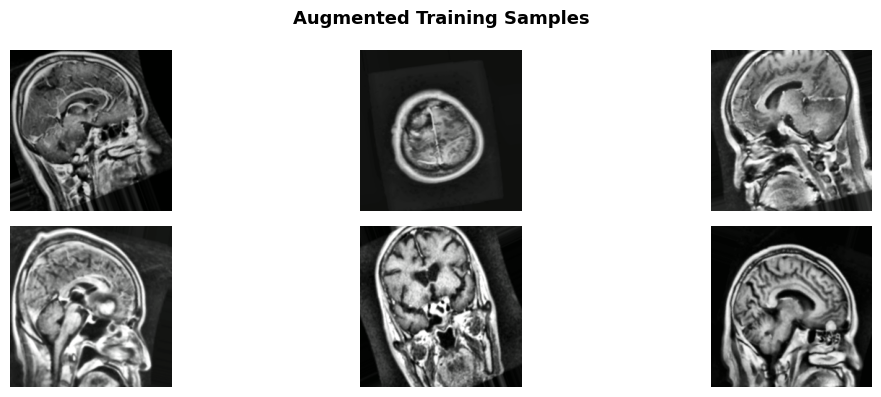

In [8]:
# ── Visualise augmented samples ──────────────────────────────────────────────
sample_imgs, _ = next(train_gen)
# De-normalise for display (undo resnet preprocess_input roughly)
display_imgs = sample_imgs[:6].copy()
display_imgs = display_imgs + [103.939, 116.779, 123.68]  # add back means
display_imgs = np.clip(display_imgs, 0, 255).astype('uint8')

plt.figure(figsize=(12, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(display_imgs[i])
    plt.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Build Model ──────────────────────────────────────────────────────────────
def build_resnet50_model(num_classes, trainable_base=False, l2_reg=1e-4):
    """
    ResNet50 feature extractor + custom classification head.
    BatchNorm layers are always frozen (avoids instability with small batches).
    """
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=inp
    )

    # Freeze/unfreeze base
    base.trainable = trainable_base

    # Always freeze BatchNorm layers to keep running statistics stable
    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    # ── Classification Head ──────────────────────────────────────────────────
    x = base.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(1024, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(0.50)(x)

    x = Dense(512, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(0.40)(x)

    x = Dense(256, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(0.30)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=outputs)
    return model, base


model, base_model = build_resnet50_model(NUM_CLASSES, trainable_base=False)

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Total layers : {len(model.layers)}")
print(f"Trainable    : {trainable_count}  (head only in Stage 1)")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Total layers : 186
Trainable    : 11  (head only in Stage 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 26,350,212 (100.52 MB)

 Trainable params: 2,758,916 (10.52 MB)

 Non-trainable params: 23,591,296 (89.99 MB)

In [10]:
# ── Stage 1 Callbacks ────────────────────────────────────────────────────────
ckpt_stage1 = os.path.join(MODEL_SAVE_PATH, 'best_stage1.h5')

callbacks_stage1 = [
    ModelCheckpoint(ckpt_stage1, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

# Label smoothing helps generalisation for medical images
model.compile(
    optimizer=Adam(learning_rate=STAGE1_LR, clipnorm=1.0),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("\n" + "="*60)
print(" STAGE 1 — Training head only (base frozen)")
print("="*60)

history1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=STAGE1_EPOCHS,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks_stage1,
    verbose=1
)

s1_val_acc = max(history1.history['val_accuracy'])
print(f"\nStage 1 best val accuracy: {s1_val_acc:.4f}")


 STAGE 1 — Training head only (base frozen)
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.5839 - loss: 1.3423
Epoch 1: val_accuracy improved from None to 0.70312, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 873ms/step - accuracy: 0.6846 - loss: 1.1486 - val_accuracy: 0.7031 - val_loss: 1.5225 - learning_rate: 0.0010
Epoch 2/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.7500 - loss: 1.2025
Epoch 2: val_accuracy improved from 0.70312 to 0.71875, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7500 - loss: 1.2025 - val_accuracy: 0.7188 - val_loss: 1.4795 - learning_rate: 0.0010
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7853 - loss: 0.9582
Epoch 3: val_accuracy improved from 0.71875 to 0.84375, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 520ms/step - accuracy: 0.7928 - loss: 0.9412 - val_accuracy: 0.8438 - val_loss: 1.0404 - learning_rate: 0.0010
Epoch 4/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8125 - loss: 0.9654
Epoch 4: val_accuracy did not improve from 0.84375
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8125 - loss: 0.9654 - val_accuracy: 0.8438 - val_loss: 1.0253 - learning_rate: 0.0010
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8064 - loss: 0.9171
Epoch 5: val_accuracy improved from 0.84375 to 0.86328, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5



Epoch 5: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 535ms/step - accuracy: 0.8012 - loss: 0.9248 - val_accuracy: 0.8633 - val_loss: 0.8830 - learning_rate: 0.0010
Epoch 6/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.6562 - loss: 0.9939
Epoch 6: val_accuracy did not improve from 0.86328
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6562 - loss: 0.9939 - val_accuracy: 0.8633 - val_loss: 0.8803 - learning_rate: 0.0010
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8467 - loss: 0.8387
Epoch 7: val_accuracy did not improve from 0.86328
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 521ms/step - accuracy: 0.8392 - loss: 0.8535 - val_accuracy: 0.8633 - val_loss: 0.8271 - learning_rate: 0.0010
Epoch 8/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.8750 - loss: 0.7774
Epoch 8: val_accuracy improved from 0.86328 to 0.87109, saving model to /content/drive/MyDrive/bra


Epoch 8: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.8750 - loss: 0.7774 - val_accuracy: 0.8711 - val_loss: 0.8295 - learning_rate: 0.0010
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.8456 - loss: 0.8458
Epoch 9: val_accuracy did not improve from 0.87109
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 525ms/step - accuracy: 0.8476 - loss: 0.8417 - val_accuracy: 0.8477 - val_loss: 0.8728 - learning_rate: 0.0010
Epoch 10/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.8125 - loss: 0.9778
Epoch 10: val_accuracy did not improve from 0.87109

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8125 - loss: 0.9778 - val_accuracy: 0.8516 - val_loss: 0.8789 - learning_rate: 0.0010
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8617 - loss: 0.7997
Epoch 11: val_accur


Epoch 11: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 524ms/step - accuracy: 0.8648 - loss: 0.8001 - val_accuracy: 0.8828 - val_loss: 0.7797 - learning_rate: 5.0000e-04
Epoch 12/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.8125 - loss: 0.8995
Epoch 12: val_accuracy did not improve from 0.88281
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8125 - loss: 0.8995 - val_accuracy: 0.8828 - val_loss: 0.7803 - learning_rate: 5.0000e-04
Epoch 13/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.8786 - loss: 0.7721
Epoch 13: val_accuracy did not improve from 0.88281
71/71 ━━━━━━━━━━━━━━━━━━━━ 36s 499ms/step - accuracy: 0.8799 - loss: 0.7528 - val_accuracy: 0.8750 - val_loss: 0.7762 - learning_rate: 5.0000e-04
Epoch 14/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.8438 - loss: 0.9730
Epoch 14: val_accuracy did not improve from 0.88281
71/71 ━━━━━━━━━━━━━━━━━━━━ 1


Epoch 19: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 39s 552ms/step - accuracy: 0.8918 - loss: 0.7100 - val_accuracy: 0.8984 - val_loss: 0.6857 - learning_rate: 5.0000e-04
Epoch 20/20
 1/71 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.8438 - loss: 0.8847
Epoch 20: val_accuracy improved from 0.89844 to 0.90234, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5



Epoch 20: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage1.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8438 - loss: 0.8847 - val_accuracy: 0.9023 - val_loss: 0.6858 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 19.

Stage 1 best val accuracy: 0.9023


In [11]:
# ── Stage 2 — Unfreeze top layers & fine-tune ────────────────────────────────
print(f"Unfreezing last {UNFREEZE_LAYERS} layers of ResNet50...")
base_model.trainable = True

# Freeze all except the last UNFREEZE_LAYERS
for layer in base_model.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

# Keep ALL BatchNorm layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

fine_tune_trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreeze: {fine_tune_trainable}")

# ── Cosine decay schedule ────────────────────────────────────────────────────
total_steps  = STAGE2_EPOCHS * steps_per_epoch
warmup_steps = 2 * steps_per_epoch

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=STAGE2_LR,
    decay_steps=total_steps,
    alpha=1e-6   # minimum LR
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule, clipnorm=1.0),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

ckpt_stage2 = os.path.join(MODEL_SAVE_PATH, 'best_stage2.h5')

callbacks_stage2 = [
    ModelCheckpoint(ckpt_stage2, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
]

print("\n" + "="*60)
print(f" STAGE 2 — Fine-tuning last {UNFREEZE_LAYERS} ResNet50 layers")
print("="*60)

history2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=STAGE2_EPOCHS,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks_stage2,
    verbose=1
)

s2_val_acc = max(history2.history['val_accuracy'])
print(f"\nStage 2 best val accuracy: {s2_val_acc:.4f}")

Unfreezing last 40 layers of ResNet50...
Trainable layers after unfreeze: 39

 STAGE 2 — Fine-tuning last 40 ResNet50 layers
Epoch 1/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.8801 - loss: 0.7393
Epoch 1: val_accuracy improved from None to 0.86719, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 79s 750ms/step - accuracy: 0.8887 - loss: 0.7293 - val_accuracy: 0.8672 - val_loss: 0.7533
Epoch 2/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.8750 - loss: 0.6657
Epoch 2: val_accuracy improved from 0.86719 to 0.87109, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8750 - loss: 0.6657 - val_accuracy: 0.8711 - val_loss: 0.7473
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9222 - loss: 0.6613
Epoch 3: val_accuracy did not improve from 0.87109
71/71 ━━━━━━━━━━━━━━━━━━━━ 36s 502ms/step - accuracy: 0.9108 - loss: 0.6762 - val_accuracy: 0.8672 - val_loss: 0.7247
Epoch 4/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.9688 - loss: 0.5694
Epoch 4: val_accuracy did not improve from 0.87109
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9688 - loss: 0.5694 - val_accuracy: 0.8672 - val_loss: 0.7253
Epoch 5/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9266 - loss: 0.6509
Epoch 5: val_accuracy did not improve from 0.87109
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 515ms/step - accuracy: 0.9249 - loss: 0.6502 - val_accuracy: 0.8633 - val_loss: 0.7148
Ep


Epoch 7: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 44s 575ms/step - accuracy: 0.9355 - loss: 0.6177 - val_accuracy: 0.9023 - val_loss: 0.6974
Epoch 8/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 12s 180ms/step - accuracy: 0.8750 - loss: 0.8692
Epoch 8: val_accuracy improved from 0.90234 to 0.90625, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5



Epoch 8: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8750 - loss: 0.8692 - val_accuracy: 0.9062 - val_loss: 0.6930
Epoch 9/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9352 - loss: 0.6162
Epoch 9: val_accuracy improved from 0.90625 to 0.91406, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5


...


Epoch 11: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9519 - loss: 0.5894 - val_accuracy: 0.9375 - val_loss: 0.5881
Epoch 12/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.9688 - loss: 0.6364
Epoch 12: val_accuracy improved from 0.93750 to 0.94141, saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5



Epoch 12: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.9688 - loss: 0.6364 - val_accuracy: 0.9414 - val_loss: 0.5903
Epoch 13/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9596 - loss: 0.5873
Epoch 13: val_accuracy did not improve from 0.94141
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 568ms/step - accuracy: 0.9607 - loss: 0.5792 - val_accuracy: 0.9102 - val_loss: 0.6230
Epoch 14/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 1.0000 - loss: 0.4848
Epoch 14: val_accuracy did not improve from 0.94141
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.4848 - val_accuracy: 0.9062 - val_loss: 0.6274
Epoch 15/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9653 - loss: 0.5624
Epoch 15: val_accuracy did not improve from 0.94141
71/71 ━━━━━━━━━━━━━━━━━━━━ 75s 479ms/step - accuracy: 0.9651 - loss: 0.5611 - val_accuracy: 0.9336 - val_loss: 0


Epoch 21: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 685ms/step - accuracy: 0.9766 - loss: 0.5197 - val_accuracy: 0.9492 - val_loss: 0.5602
Epoch 22/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.9375 - loss: 0.5728
Epoch 22: val_accuracy did not improve from 0.94922
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9375 - loss: 0.5728 - val_accuracy: 0.9375 - val_loss: 0.5604
Epoch 23/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9840 - loss: 0.5081
Epoch 23: val_accuracy did not improve from 0.94922
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 573ms/step - accuracy: 0.9801 - loss: 0.5134 - val_accuracy: 0.8906 - val_loss: 0.6505
Epoch 24/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.9688 - loss: 0.5334
Epoch 24: val_accuracy did not improve from 0.94922
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9688 - loss: 0.5334 - val_accuracy: 0.8906 - val_loss: 0


Epoch 26: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - accuracy: 0.9688 - loss: 0.5019 - val_accuracy: 0.9531 - val_loss: 0.5696
Epoch 27/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9883 - loss: 0.5002
Epoch 27: val_accuracy did not improve from 0.95312
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 571ms/step - accuracy: 0.9876 - loss: 0.5021 - val_accuracy: 0.9180 - val_loss: 0.6132
Epoch 28/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 1.0000 - loss: 0.4592
Epoch 28: val_accuracy did not improve from 0.95312
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.4592 - val_accuracy: 0.9258 - val_loss: 0.6037
Epoch 29/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9893 - loss: 0.4956
Epoch 29: val_accuracy did not improve from 0.95312
71/71 ━━━━━━━━━━━━━━━━━━━━ 35s 487ms/step - accuracy: 0.9894 - loss: 0.4923 - val_accuracy: 0.9531 - val_loss: 


Epoch 31: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/best_stage2.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 52s 659ms/step - accuracy: 0.9867 - loss: 0.4992 - val_accuracy: 0.9609 - val_loss: 0.5442
Epoch 32/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 1.0000 - loss: 0.5045
Epoch 32: val_accuracy did not improve from 0.96094
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.5045 - val_accuracy: 0.9570 - val_loss: 0.5452
Epoch 33/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9864 - loss: 0.4876
Epoch 33: val_accuracy did not improve from 0.96094
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 565ms/step - accuracy: 0.9872 - loss: 0.4860 - val_accuracy: 0.9258 - val_loss: 0.6137
Epoch 34/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.9688 - loss: 0.5140
Epoch 34: val_accuracy did not improve from 0.96094
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9688 - loss: 0.5140 - val_accuracy: 0.9336 - val_loss: 0

In [12]:
# ── Load Best Checkpoint ─────────────────────────────────────────────────────
# Reload the best checkpoint from Stage 2 (highest val_accuracy)
model.load_weights(ckpt_stage2)
print("Best Stage 2 weights loaded.")

Best Stage 2 weights loaded.


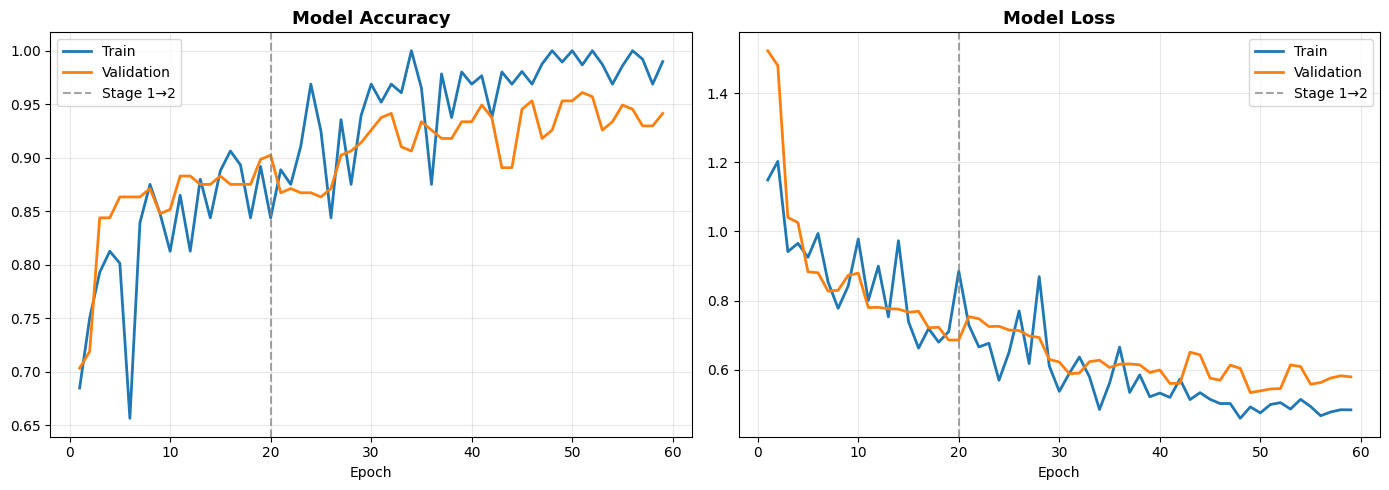

In [13]:
# ── Plot Training History ────────────────────────────────────────────────────
def merge_histories(h1, h2, keys=('accuracy', 'val_accuracy', 'loss', 'val_loss')):
    """Concatenate history from Stage 1 and Stage 2."""
    merged = {}
    for k in keys:
        merged[k] = h1.history.get(k, []) + h2.history.get(k, [])
    return merged

hist = merge_histories(history1, history2)
stage1_len = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Model Accuracy', 'Model Loss']
):
    train_key, val_key = metric
    epochs_range = range(1, len(hist[train_key]) + 1)
    ax.plot(epochs_range, hist[train_key], label='Train', linewidth=2)
    ax.plot(epochs_range, hist[val_key],   label='Validation', linewidth=2)
    ax.axvline(x=stage1_len, color='gray', linestyle='--', alpha=0.7, label='Stage 1→2')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(MODEL_SAVE_PATH, 'training_history.png'), dpi=150)
plt.show()

In [14]:
# ── Standard Test Evaluation ─────────────────────────────────────────────────
loss, acc = model.evaluate(test_gen, verbose=0)
print(f"Standard Test Loss     : {loss:.4f}")
print(f"Standard Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")

Standard Test Loss     : 0.5630
Standard Test Accuracy : 0.9443  (94.43%)


In [15]:
# ── Test-Time Augmentation (TTA) ─────────────────────────────────────────────
# Average predictions over multiple augmented versions of each test image
# This typically boosts accuracy by 1-3%.

TTA_STEPS = 10  # number of augmented passes per image

tta_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

print(f"Running TTA with {TTA_STEPS} augmented passes ...")
tta_probs = np.zeros((len(X_test), NUM_CLASSES))

for step in range(TTA_STEPS):
    tta_gen = tta_datagen.flow(X_test, y_test_cat,
                               batch_size=BATCH_SIZE, shuffle=False)
    probs = model.predict(tta_gen, verbose=0)
    tta_probs += probs
    if (step + 1) % 2 == 0:
        print(f"  Pass {step+1}/{TTA_STEPS} done")

tta_probs /= TTA_STEPS
y_pred_tta  = np.argmax(tta_probs, axis=1)
tta_accuracy = accuracy_score(y_test, y_pred_tta)
print(f"\nTTA Test Accuracy : {tta_accuracy:.4f}  ({tta_accuracy*100:.2f}%)")

Running TTA with 10 augmented passes ...
  Pass 2/10 done
  Pass 4/10 done
  Pass 6/10 done
  Pass 8/10 done
  Pass 10/10 done

TTA Test Accuracy : 0.9582  (95.82%)


In [16]:
# ── Use best prediction method ───────────────────────────────────────────────
# Standard prediction for metrics
X_test_pp   = preprocess_input(X_test.astype('float32'))
y_pred_probs = model.predict(X_test_pp, batch_size=BATCH_SIZE, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_test

# Final accuracy (pick TTA if better)
standard_acc = accuracy_score(y_true, y_pred)
if tta_accuracy > standard_acc:
    y_pred_final = y_pred_tta
    final_acc    = tta_accuracy
    method_used  = "TTA"
else:
    y_pred_final = y_pred
    final_acc    = standard_acc
    method_used  = "Standard"

print(f"Standard Accuracy : {standard_acc*100:.2f}%")
print(f"TTA Accuracy      : {tta_accuracy*100:.2f}%")
print(f"\nUsing → {method_used}  |  Final Accuracy: {final_acc*100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 713ms/step
Standard Accuracy : 94.43%
TTA Accuracy      : 95.82%

Using → TTA  |  Final Accuracy: 95.82%


In [17]:
# ── Overall Metrics ──────────────────────────────────────────────────────────
overall_precision = precision_score(y_true, y_pred_final, average='weighted', zero_division=0)
overall_recall    = recall_score   (y_true, y_pred_final, average='weighted', zero_division=0)
overall_f1        = f1_score       (y_true, y_pred_final, average='weighted', zero_division=0)

macro_precision = precision_score(y_true, y_pred_final, average='macro', zero_division=0)
macro_recall    = recall_score   (y_true, y_pred_final, average='macro', zero_division=0)
macro_f1        = f1_score       (y_true, y_pred_final, average='macro', zero_division=0)

print("=" * 60)
print("OVERALL METRICS")
print("=" * 60)
print(f"Accuracy  (final) : {final_acc:.4f}  ({final_acc*100:.2f}%)")
print(f"Weighted Precision: {overall_precision:.4f}")
print(f"Weighted Recall   : {overall_recall:.4f}")
print(f"Weighted F1-Score : {overall_f1:.4f}")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1-Score    : {macro_f1:.4f}")

if final_acc >= 0.90:
    print("\n  TARGET ACHIEVED: Accuracy ≥ 90%")
else:
    print(f"\n   Accuracy {final_acc*100:.2f}% — consider more epochs or data")

OVERALL METRICS
Accuracy  (final) : 0.9582  (95.82%)
Weighted Precision: 0.9590
Weighted Recall   : 0.9582
Weighted F1-Score : 0.9583
Macro Precision   : 0.9643
Macro Recall      : 0.9569
Macro F1-Score    : 0.9603

  TARGET ACHIEVED: Accuracy ≥ 90%


In [18]:
# ── Classification Report ────────────────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
report = classification_report(
    y_true, y_pred_final,
    target_names=class_names,
    digits=4
)
print(report)

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    glioma_tumor     0.9877    0.9639    0.9756        83
meningioma_tumor     0.9277    0.9390    0.9333        82
        no_tumor     1.0000    0.9487    0.9737        39
 pituitary_tumor     0.9419    0.9759    0.9586        83

        accuracy                         0.9582       287
       macro avg     0.9643    0.9569    0.9603       287
    weighted avg     0.9590    0.9582    0.9583       287



In [19]:
# ── Class-wise Detailed Metrics ──────────────────────────────────────────────
print("=" * 60)
print("CLASS-WISE DETAILED METRICS")
print("=" * 60)

for i, class_name in enumerate(class_names):
    class_indices = np.where(y_true == i)[0]
    if len(class_indices) == 0:
        continue
    class_preds = y_pred_final[class_indices]
    tp  = np.sum(class_preds == i)
    fp  = np.sum(y_pred_final == i) - tp
    fn  = len(class_indices) - tp
    cls_acc  = tp / len(class_indices)
    cls_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    cls_rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    cls_f1   = 2 * cls_prec * cls_rec / (cls_prec + cls_rec) if (cls_prec + cls_rec) > 0 else 0

    print(f"\n{class_name}:")
    print(f"  Accuracy : {cls_acc*100:.2f}%  ({tp}/{len(class_indices)})")
    print(f"  Precision: {cls_prec:.4f}")
    print(f"  Recall   : {cls_rec:.4f}")
    print(f"  F1-Score : {cls_f1:.4f}")
    print(f"  TP={tp}  FP={fp}  FN={fn}")

CLASS-WISE DETAILED METRICS

glioma_tumor:
  Accuracy : 96.39%  (80/83)
  Precision: 0.9877
  Recall   : 0.9639
  F1-Score : 0.9756
  TP=80  FP=1  FN=3

meningioma_tumor:
  Accuracy : 93.90%  (77/82)
  Precision: 0.9277
  Recall   : 0.9390
  F1-Score : 0.9333
  TP=77  FP=6  FN=5

no_tumor:
  Accuracy : 94.87%  (37/39)
  Precision: 1.0000
  Recall   : 0.9487
  F1-Score : 0.9737
  TP=37  FP=0  FN=2

pituitary_tumor:
  Accuracy : 97.59%  (81/83)
  Precision: 0.9419
  Recall   : 0.9759
  F1-Score : 0.9586
  TP=81  FP=5  FN=2


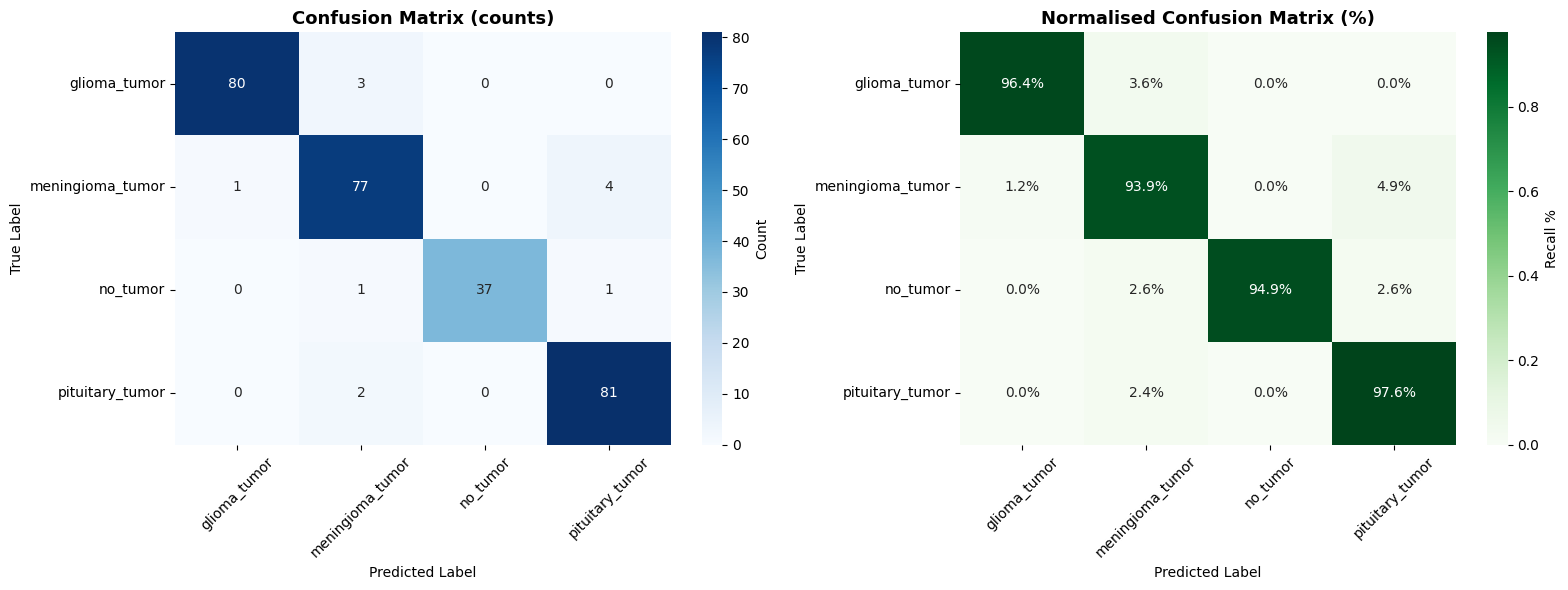

In [20]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred_final)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Recall %'})
axes[1].set_title('Normalised Confusion Matrix (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(MODEL_SAVE_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

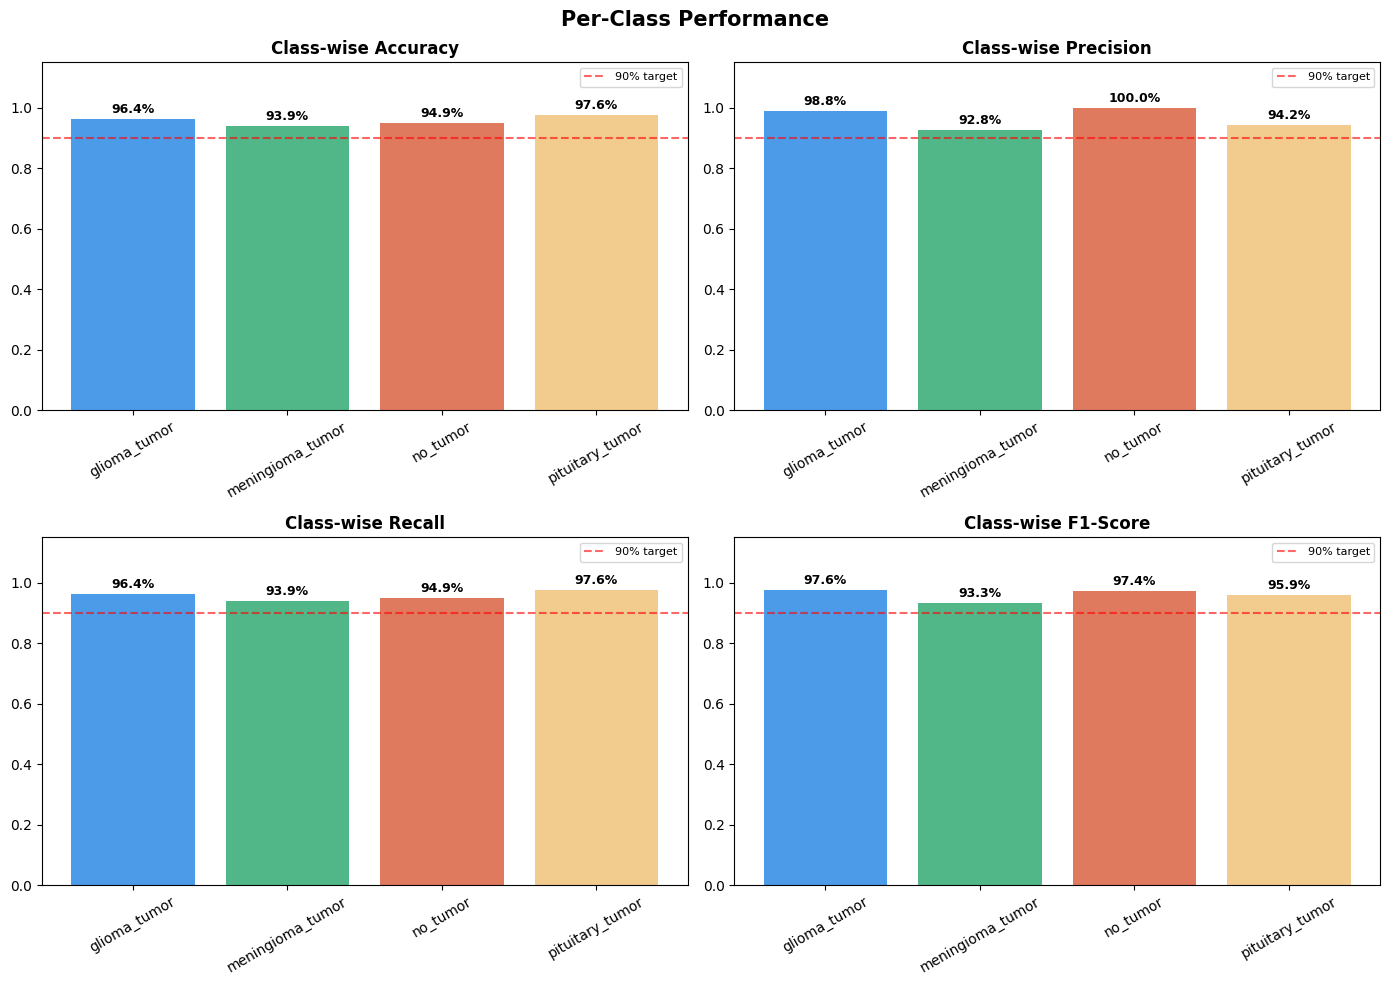

In [21]:
# ── Per-class metrics bar chart ──────────────────────────────────────────────
class_accs, class_precs, class_recs, class_f1s = [], [], [], []

for i in range(NUM_CLASSES):
    idxs = np.where(y_true == i)[0]
    preds = y_pred_final[idxs]
    tp  = np.sum(preds == i)
    fp  = np.sum(y_pred_final == i) - tp
    fn  = len(idxs) - tp
    p   = tp / (tp + fp) if tp + fp else 0
    r   = tp / (tp + fn) if tp + fn else 0
    class_accs.append(tp / len(idxs))
    class_precs.append(p)
    class_recs.append(r)
    class_f1s.append(2 * p * r / (p + r) if p + r else 0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#4C9BE8', '#52B788', '#E07A5F', '#F2CC8F']

for ax, values, title in zip(
    axes.flatten(),
    [class_accs, class_precs, class_recs, class_f1s],
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
):
    bars = ax.bar(class_names, values, color=colors[:NUM_CLASSES])
    ax.set_title(f'Class-wise {title}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.6, label='90% target')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Per-Class Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(MODEL_SAVE_PATH, 'per_class_metrics.png'), dpi=150)
plt.show()

In [22]:
# ── Save Model & Artifacts ───────────────────────────────────────────────────

# .keras format (recommended for Keras 3)
keras_path = os.path.join(MODEL_SAVE_PATH, 'resnet50_brain_tumor_final.keras')
model.save(keras_path)
print(f"Keras model saved at: {keras_path}")

# H5 format (also still works as backup)
h5_path = os.path.join(MODEL_SAVE_PATH, 'resnet50_brain_tumor_final.h5')
model.save(h5_path)
print(f"H5 model saved at  : {h5_path}")

# Export as SavedModel (for TFLite / TFServing) — use export() not save()
savedmodel_path = os.path.join(MODEL_SAVE_PATH, 'resnet50_brain_tumor_savedmodel')
model.export(savedmodel_path)
print(f"SavedModel exported at: {savedmodel_path}")

# Class names
cn_path = os.path.join(MODEL_SAVE_PATH, 'class_names.pkl')
with open(cn_path, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Class names saved at: {cn_path}")

# History
hist_path = os.path.join(MODEL_SAVE_PATH, 'training_history.pkl')
with open(hist_path, 'wb') as f:
    pickle.dump({
        'stage1': history1.history,
        'stage2': history2.history
    }, f)
print(f"Training history saved at: {hist_path}")

Keras model saved at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/resnet50_brain_tumor_final.keras
H5 model saved at  : /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/resnet50_brain_tumor_final.h5
Saved artifact at '/content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/resnet50_brain_tumor_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135628358098704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135628358099472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135628358098896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135628358100048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135628358097168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135628358096976: TensorSpec(shape=()

In [23]:
# ── Save Metrics Report ──────────────────────────────────────────────────────
metrics_path = os.path.join(MODEL_SAVE_PATH, 'evaluation_metrics.txt')
with open(metrics_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("BRAIN TUMOR MRI CLASSIFICATION — ResNet50 v2\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Method used       : {method_used}\n")
    f.write(f"Final Accuracy    : {final_acc:.4f}  ({final_acc*100:.2f}%)\n")
    f.write(f"Standard Accuracy : {standard_acc:.4f}  ({standard_acc*100:.2f}%)\n")
    f.write(f"TTA Accuracy      : {tta_accuracy:.4f}  ({tta_accuracy*100:.2f}%)\n\n")
    f.write(f"Weighted Precision: {overall_precision:.4f}\n")
    f.write(f"Weighted Recall   : {overall_recall:.4f}\n")
    f.write(f"Weighted F1-Score : {overall_f1:.4f}\n\n")
    f.write(f"Macro Precision   : {macro_precision:.4f}\n")
    f.write(f"Macro Recall      : {macro_recall:.4f}\n")
    f.write(f"Macro F1-Score    : {macro_f1:.4f}\n\n")
    f.write("=" * 60 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("=" * 60 + "\n")
    f.write(report)
    f.write("\n=" * 60 + "\n")
    f.write("CONFUSION MATRIX\n")
    f.write("=" * 60 + "\n")
    f.write(str(cm) + "\n")

print(f"Metrics report saved at: {metrics_path}")

Metrics report saved at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50_v2/evaluation_metrics.txt


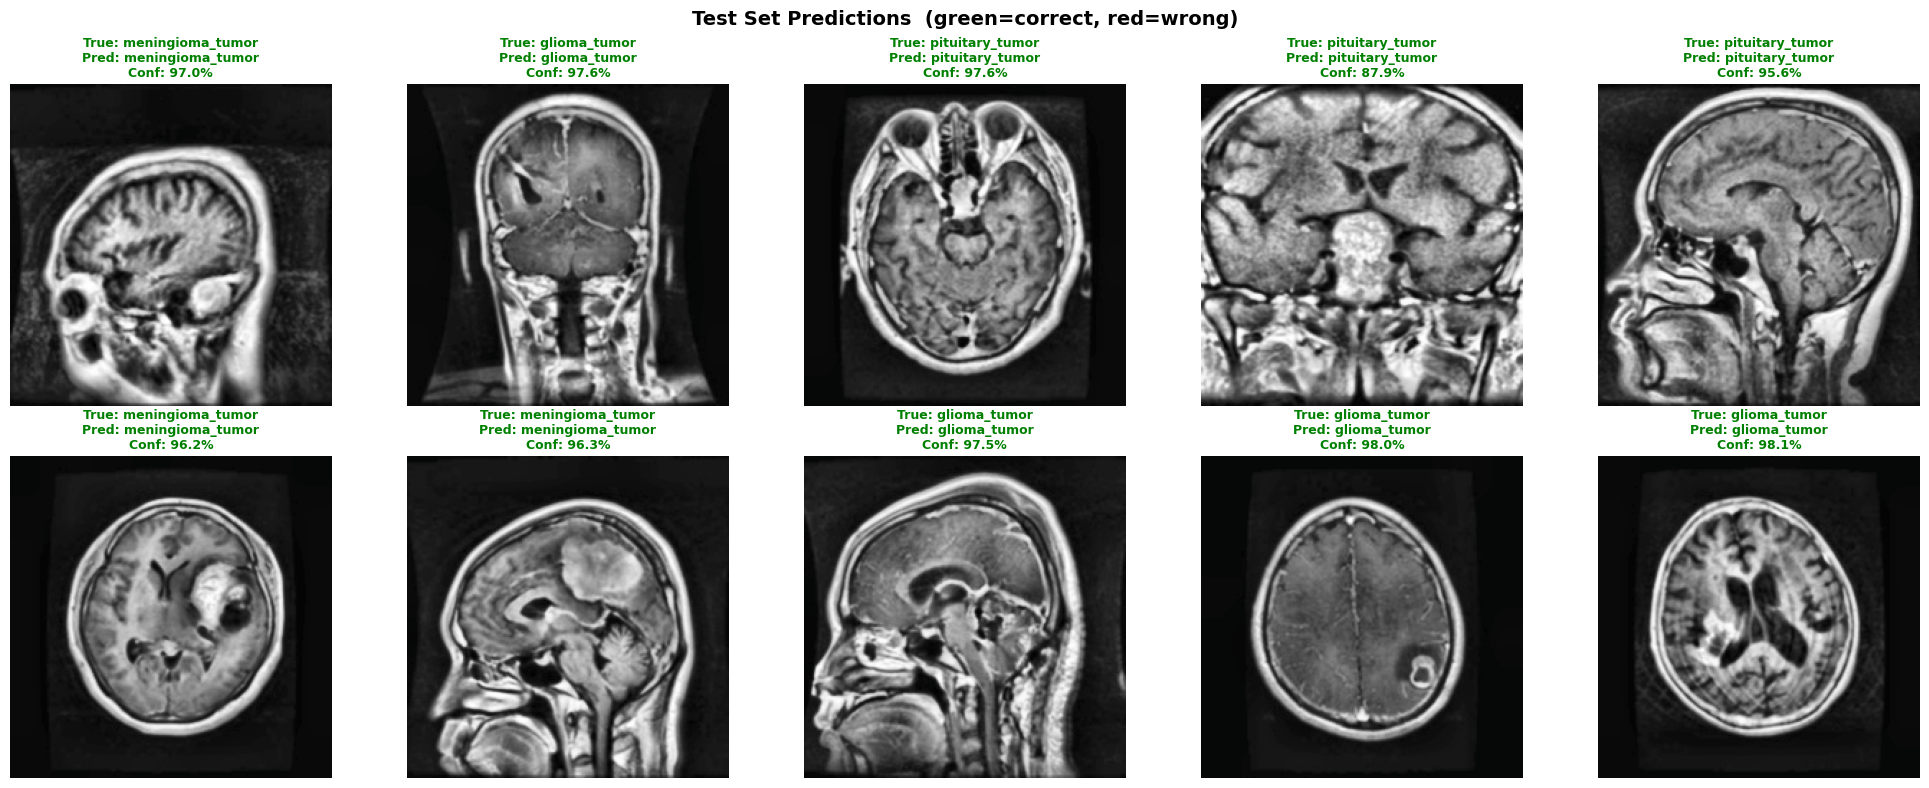

In [24]:
# ── Prediction Helper Function ───────────────────────────────────────────────
def predict_single_image(model, img_array, class_names, tta=True, tta_steps=5):
    """
    Predict the class of a single MRI image.

    Args:
        model       : Trained Keras model
        img_array   : H×W×3 uint8 numpy array (already resized to 224×224)
        class_names : List of class name strings
        tta         : Whether to use test-time augmentation
        tta_steps   : Number of TTA passes

    Returns:
        predicted_class (str), confidence (float), all_probs (array)
    """
    from tensorflow.keras.applications.resnet50 import preprocess_input

    if not tta:
        img = preprocess_input(img_array.astype('float32'))
        img = np.expand_dims(img, axis=0)
        probs = model.predict(img, verbose=0)[0]
    else:
        aug = ImageDataGenerator(
            rotation_range=15, width_shift_range=0.08,
            height_shift_range=0.08, zoom_range=0.10,
            horizontal_flip=True, fill_mode='nearest'
        )
        img_exp = np.expand_dims(img_array, 0)  # (1,224,224,3)
        probs_acc = np.zeros(len(class_names))
        for _ in range(tta_steps):
            aug_img = next(aug.flow(img_exp, batch_size=1))
            aug_img = preprocess_input(aug_img.astype('float32'))
            probs_acc += model.predict(aug_img, verbose=0)[0]
        probs = probs_acc / tta_steps

    pred_idx = np.argmax(probs)
    return class_names[pred_idx], probs[pred_idx], probs


# ── Visualise random test predictions ───────────────────────────────────────
num_samples = min(10, len(X_test))
rand_idx    = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(20, 8))
n_cols = 5
n_rows = (num_samples + n_cols - 1) // n_cols

for plot_i, i in enumerate(rand_idx):
    img       = X_test[i]
    true_lbl  = class_names[y_test[i]]
    pred_lbl, conf, all_p = predict_single_image(model, img, class_names, tta=True)

    ax = plt.subplot(n_rows, n_cols, plot_i + 1)
    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.1%}',
        fontsize=9, color=color, fontweight='bold'
    )

plt.suptitle('Test Set Predictions  (green=correct, red=wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, 'sample_predictions.png'), dpi=150)
plt.show()

In [25]:
# ── Final Summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Dataset           : Brain Tumor MRI ({NUM_CLASSES} classes)")
print(f"Classes           : {class_names}")
print(f"Train / Val / Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Model             : ResNet50 (two-stage fine-tuning)")
print(f"  Stage 1 best val: {s1_val_acc*100:.2f}%")
print(f"  Stage 2 best val: {s2_val_acc*100:.2f}%")
print(f"Evaluation method : {method_used}")
print(f"Final Test Acc    : {final_acc*100:.2f}%")
print(f"Weighted F1       : {overall_f1*100:.2f}%")
print("=" * 60)
if final_acc >= 0.90:
    print("  Goal achieved: Accuracy ≥ 90%")
else:
    print(f"  Current accuracy {final_acc*100:.1f}% — tips to improve:")
    print("   • Increase STAGE2_EPOCHS to 60")
    print("   • Increase UNFREEZE_LAYERS to 60")
    print("   • Add more training data / class balancing")
print("=" * 60)


FINAL SUMMARY
Dataset           : Brain Tumor MRI (4 classes)
Classes           : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Train / Val / Test: 2296 / 287 / 287
Model             : ResNet50 (two-stage fine-tuning)
  Stage 1 best val: 90.23%
  Stage 2 best val: 96.09%
Evaluation method : TTA
Final Test Acc    : 95.82%
Weighted F1       : 95.83%
  Goal achieved: Accuracy ≥ 90%
